In [1]:
!pip install pandasql

  Preparing metadata (setup.py) ... done
  Created wheel for pandasql: filename=pandasql-0.7.3-py3-none-any.whl size=26773 sha256=34bc2cddb38ec2910ad0ebe6ee987eb5fc00492b4451a5b6fa5e72f031e9bc07
  Stored in directory: /root/.cache/pip/wheels/68/5d/a5/edc271b998f909801d7956959f699b976cc9896075dc47c153
Successfully built pandasql


In [2]:
import pandas as pd
from pandasql import sqldf
import numpy as np
from datetime import datetime, date, timedelta

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

In [3]:
# Загружаем таблицу - это будет симуляция БД
df = pd.read_excel('Тестовое Точка_фин.аналитик.xlsx')
df

,USER_ID,EVENT_DATE
0,304640308,2024-12-25
1,304611630,2024-10-26
2,304184513,2024-07-26
3,304279402,2024-05-22
4,304266625,2025-04-07
...,...,...
3877,304337716,2025-03-24
3878,304289318,2024-10-13
3879,304815589,2025-02-18
3880,304804603,2025-03-05


# EDA

Для анализа предоставлены логи активности пользователей за период с апрель 2024 по апрель 2025г. Данные сумме покупок отсутствуют, есть только дата покупки и идентификатор пользователя. Можно увидеть, что количество пользователей устойчиво растет на протяжении всего периода. Данные в дневной динамике очень шумные, явная недельная сезонность отсуствует. Есть "праздничные" спады активности в конце декабря/начале января и феврале 2025. Вначале есть дни, когда в день не совершено ни одной покупки. Количество повторных покупок в день в 2025г немного увеличилось, но видно, что основной рост достигается за счет увеличения количества пользователей.

В целом, поведение данных напоминает небольшой бизнес, начинающий с нуля и демонстрирующий стабильный рост. Вероятно, это нишевой продавец на маркетплейсе, работающий с узкой категорией товаров, на которую есть устойчивый спрос (не привязанным к сезону). Основная задача бизнеса на данном этапе — расширять охват аудитории.


In [4]:
df_daily = df.groupby('EVENT_DATE', as_index=False).agg(num_customers = ('USER_ID','nunique'), num_purchases = ('USER_ID','count'))\
      .merge(pd.DataFrame({"EVENT_DATE": pd.date_range(date(2024,4,1), date(2025,4,28))}), on='EVENT_DATE', how='right')\
      .assign(num_purchases_per_day = lambda df: df.num_purchases/df.num_customers).fillna(0)

df_daily

,EVENT_DATE,num_customers,num_purchases,num_purchases_per_day
0,2024-04-01,1.0,1.0,1.000000
1,2024-04-02,2.0,2.0,1.000000
2,2024-04-03,1.0,1.0,1.000000
3,2024-04-04,0.0,0.0,0.000000
4,2024-04-05,1.0,1.0,1.000000
...,...,...,...,...
388,2025-04-24,20.0,22.0,1.100000
389,2025-04-25,16.0,17.0,1.062500
390,2025-04-26,16.0,20.0,1.250000
391,2025-04-27,14.0,16.0,1.142857


## Дневная динамика

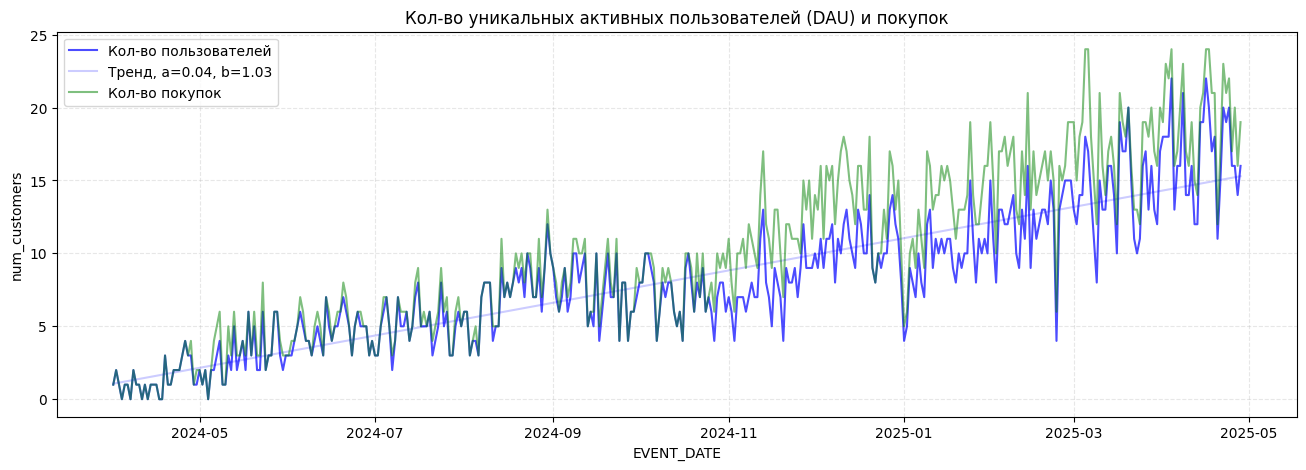

In [79]:
# Рассчитаем коэффициенты линейной регрессии для тренда
a, b = np.polyfit(np.arange(1,len(df_daily)+1), df_daily.num_customers, 1)

plt.figure(figsize=(16, 5))
plt.title('Кол-во уникальных активных пользователей (DAU) и покупок')
sns.lineplot(data=df_daily , x='EVENT_DATE', y='num_customers', color='blue', alpha=0.7, label='Кол-во пользователей')
sns.lineplot(data=df_daily , x='EVENT_DATE', y=[a*i+b for i in np.arange(1,len(df_daily)+1)], color='blue', alpha=0.2, label=f'Тренд, a={a:.2f}, b={b:.2f}')
sns.lineplot(data=df_daily , x='EVENT_DATE', y='num_purchases', color='green', alpha=0.5, label='Кол-во покупок')
plt.grid(True, linestyle="--", alpha=0.3);

## Повторные покупки

Видим, что в 2025г пользователи стали чаще совершать повторные покупки в день, а также то, что дни, когда не было ни одной покупки за день отсутствуют

>Пояснения к boxplot (диаграмма "ящик с усами")
- Горизонтальная линия в коробке — медиана (50-й процентиль)
- Верхняя  и нижняя границы коробки — 75-й и 25-й процентили
- "Усы" — 1.5 межквартильных размаха (0.75-0.25)*1.5
- Точки за пределами усов — выбросы

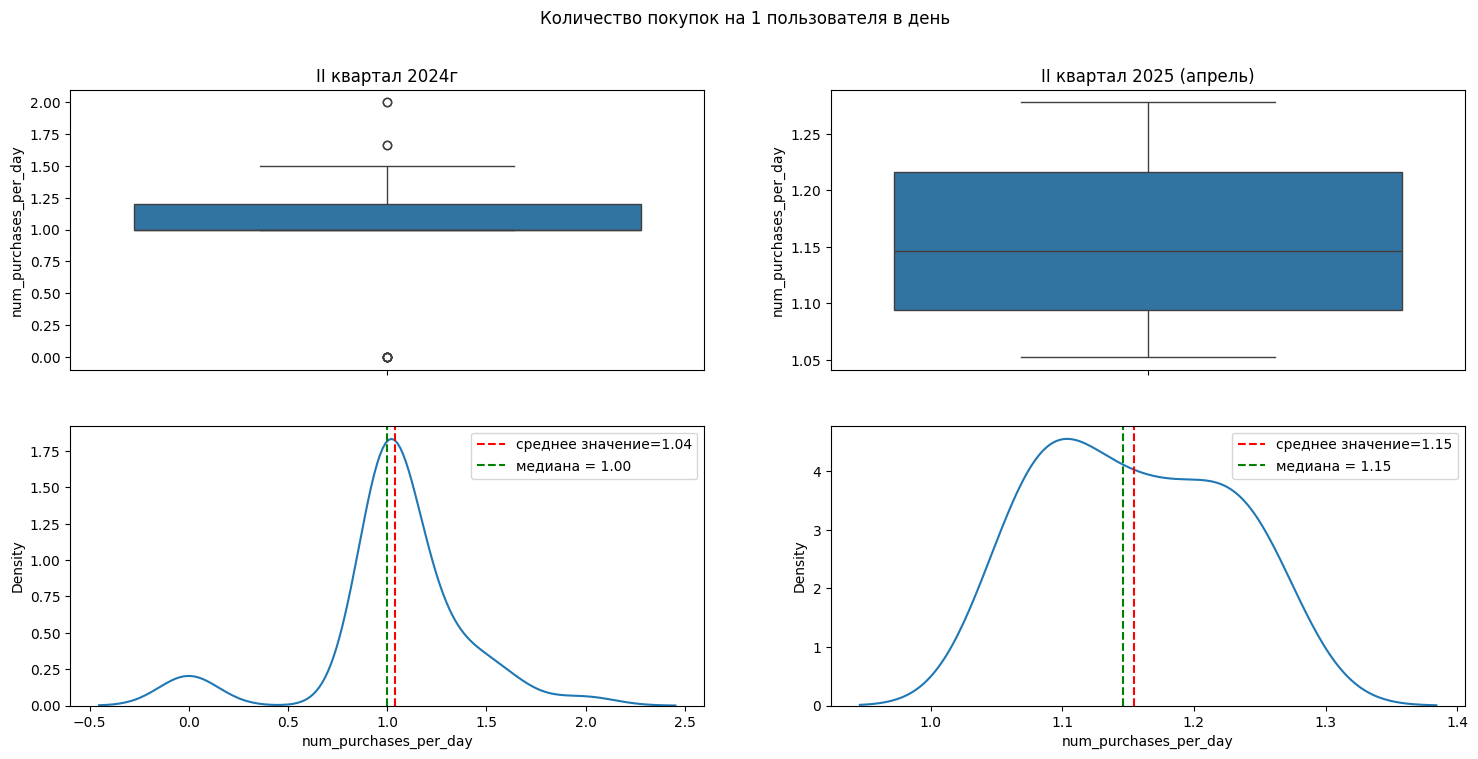

In [20]:
purchuses_1 = df_daily.query('EVENT_DATE>="2024-04-01"&EVENT_DATE<="2024-06-30"').num_purchases_per_day
purchuses_2= df_daily.query('EVENT_DATE>="2025-04-01"&EVENT_DATE<="2025-04-30"').num_purchases_per_day

fig, axes = plt.subplots(2, 2, figsize=(18, 8))
fig.suptitle('Количество покупок на 1 пользователя в день')
axes[0,0].set_title('II квартал 2024г')
sns.boxplot(ax=axes[0,0], data=purchuses_1)

axes[0,1].set_title('II квартал 2025 (апрель)')
sns.boxplot(ax=axes[0,1], data=purchuses_2)

#axes[1,0].set_title('II квартал 2024г')
sns.kdeplot(ax=axes[1,0], data=purchuses_1)
axes[1,0].axvline(x=purchuses_1.mean(), linestyle='--', color='red', label=f'среднее значение={purchuses_1.mean():.2f}')
axes[1,0].axvline(x=purchuses_1.median(), linestyle='--', color='green', label=f'медиана = {purchuses_1.median():.2f}')
axes[1,0].legend()

#axes[1,1].set_title('II квартал 2025 (апрель)')
sns.kdeplot(ax=axes[1,1], data=purchuses_2)
axes[1,1].axvline(x=purchuses_2.mean(), linestyle='--', color='red', label=f'среднее значение={purchuses_2.mean():.2f}')
axes[1,1].axvline(x=purchuses_2.median(), linestyle='--', color='green', label=f'медиана = {purchuses_2.median():.2f}')
axes[1,1].legend();

## Недельная динамика

Недельная гранулярность очень удобна для любой метрики. По сравнению с подневной она не такая шумная, но не искажет агрегированные значения по сравнению с месячной, особенно если есть недельная цикличность (как например в месяце может быть разное кол-во дней, большее/меньшее кол-во выходных - и это делает месячные показатели не сопоставимыми друг с другом)

Здесь мы видим то, что я уже описала выше

In [76]:
df_week = df_daily.assign(week_day = lambda df: df.EVENT_DATE.dt.day_name(), week = lambda df: df.EVENT_DATE.dt.to_period('W-SUN').dt.start_time)
df_week

,EVENT_DATE,num_customers,num_purchases,num_purchases_per_day,week_day,week
0,2024-04-01,1.0,1.0,1.000000,Monday,2024-04-01
1,2024-04-02,2.0,2.0,1.000000,Tuesday,2024-04-01
2,2024-04-03,1.0,1.0,1.000000,Wednesday,2024-04-01
3,2024-04-04,0.0,0.0,0.000000,Thursday,2024-04-01
4,2024-04-05,1.0,1.0,1.000000,Friday,2024-04-01
...,...,...,...,...,...,...
388,2025-04-24,20.0,22.0,1.100000,Thursday,2025-04-21
389,2025-04-25,16.0,17.0,1.062500,Friday,2025-04-21
390,2025-04-26,16.0,20.0,1.250000,Saturday,2025-04-21
391,2025-04-27,14.0,16.0,1.142857,Sunday,2025-04-21


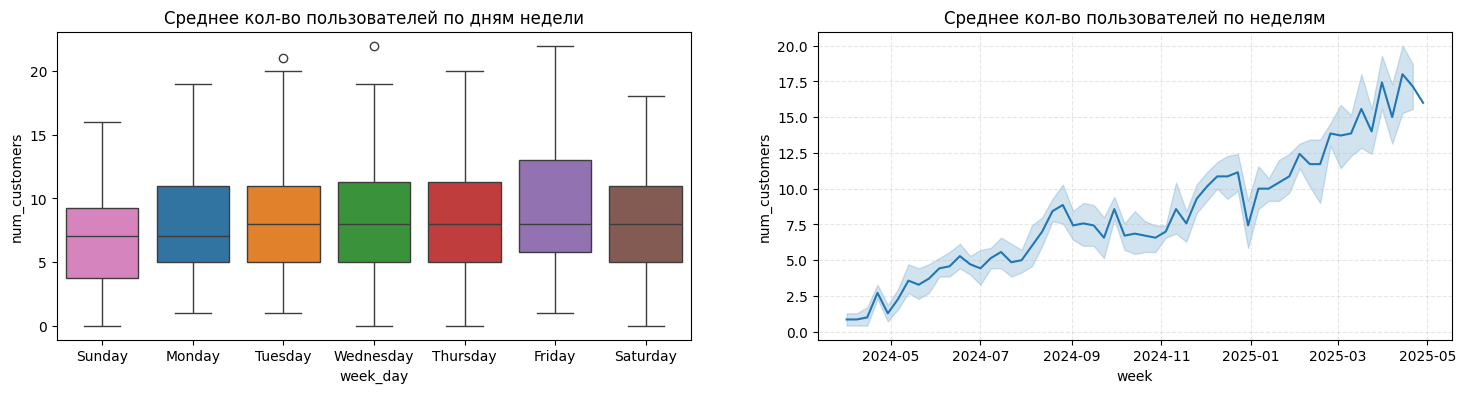

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(18, 4))
axes[0].set_title('Среднее кол-во пользователей по дням недели')
sns.boxplot(ax=axes[0], data=df_week, x='week_day', y='num_customers', hue='week_day', order=['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'])
axes[1].set_title('Среднее кол-во пользователей по неделям')
sns.lineplot(ax=axes[1], data=df_week, x='week', y='num_customers')
axes[1].grid(True, linestyle="--", alpha=0.3);

# New_users

Анализ динамики new_users по месяцам показывает, что среднее кол-во новых пользователей в месяц и медиана на уровне 8 - смещения нет, что удобно для анализа. Размах значений - от 2 (минимальное кол-во) до 12 (максимальное кол-во)

О какой то сезонности говорить мы не можем, т.к. данных не достаточно. Однако можем заметить, что в декабре 2024 был всплеск (12 новых пользователей, абсолютный максимум), после которого в январе наблюдается спад (4 новых пользователя). Такая динамика очень характерна для потребительской активности и связана с Новогодними праздниками

Аппроксимация временного ряда на линейную регрессию показывает, что тренд положительный - т.е. наблюдается устойчивый рост метрики new_users от месяца к месяцу, и за 3 месяца в среднем увеличивается на 1 пользователя

new_users характеризует темп роста активных пользователей и напрямую влияет на DAU и MAU. При стабильном удержании рост new_users обеспечивает ещё более выраженный прирост общей пользовательской базы. Кроме того, это хороший индикатор "здоровья" продукта, так как отражает эффективность привлечения новой аудитории

In [73]:
# Запрос, который возвращает кол-во новых пользователей по месяцам

query = '''
        select first_event_month, count(USER_ID) as num_first_users
        from
            (select USER_ID, strftime('%Y-%m-01', min(EVENT_DATE)) as first_event_month
            from df
            group by USER_ID) q
        group by first_event_month
        '''

new_users_monthly = sqldf(query).assign(first_event_month = lambda df: pd.to_datetime(df.first_event_month))
new_users_monthly

,first_event_month,num_first_users
0,2024-04-01,7
1,2024-05-01,9
2,2024-06-01,2
3,2024-07-01,10
4,2024-08-01,6
5,2024-09-01,3
6,2024-10-01,9
7,2024-11-01,7
8,2024-12-01,12
9,2025-01-01,4


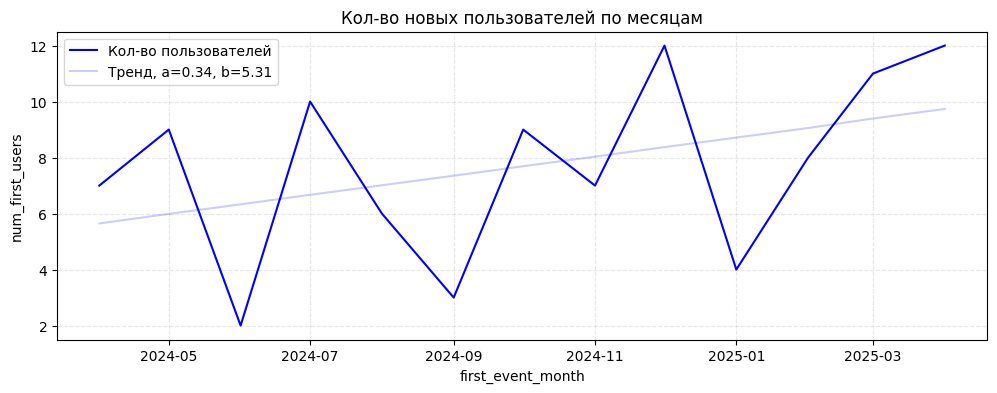

In [74]:
# Рассчитаем коэффициенты линейной регрессии для тренда
a, b = np.polyfit(np.arange(1,14), new_users_monthly.num_first_users, 1)

plt.figure(figsize=(12, 4))
plt.title('Кол-во новых пользователей по месяцам')
sns.lineplot(data=new_users_monthly , x='first_event_month', y='num_first_users', color='blue', label='Кол-во пользователей')
sns.lineplot(data=new_users_monthly , x='first_event_month', y=[a*i+b for i in np.arange(1,14)], color='blue', alpha=0.2, label=f'Тренд, a={a:.2f}, b={b:.2f}')
plt.grid(True, linestyle="--", alpha=0.3);

In [ ]:
# Основные статистики
new_users_monthly.num_first_users.describe()

,num_first_users
count,13.000000
mean,7.692308
std,3.275785
min,2.000000
25%,6.000000
50%,8.000000
75%,10.000000
max,12.000000


# MAU

Метрика MAU показывает стабильный восходящий тренд: с 7 уникальных пользователей в апреле 2024 года до 55 в апреле 2025 года. Это свидетельствует о постоянном расширении пользовательской базы и/или увеличении частоты взаимодействия пользователей с продуктом.

За год MAU выросла на 48 пользователей, что соответствует среднему приросту около 4 пользователей в месяц. Особенно резкий рост наблюдается начиная с ноября 2024 года — с 26 до 55 пользователей за 6 месяцев

Явных признаков сезонности не наблюдается, но март 2025 стал пиковым месяцем по приросту MAU (+13) — важно изучить, какие события в этот период могли повлиять (запуск фичи, промо и т.д.).

Рост MAU не замедляется — это хороший сигнал, что продукт еще не достиг насыщения рынка. Показатель свидетельствует о высокой вовлечённости и/или хорошем удержании пользователей.



In [71]:
query = '''
        select month, count(distinct user_id) as num_uniq_customers
        from
            (select user_id, strftime("%Y-%m-01", event_date) as month
            from df) q
        group by month
        '''

mau = sqldf(query).assign(month = lambda df: pd.to_datetime(df.month))
mau

,month,num_uniq_customers
0,2024-04-01,7
1,2024-05-01,15
2,2024-06-01,12
3,2024-07-01,20
4,2024-08-01,23
5,2024-09-01,21
6,2024-10-01,26
7,2024-11-01,26
8,2024-12-01,34
9,2025-01-01,31


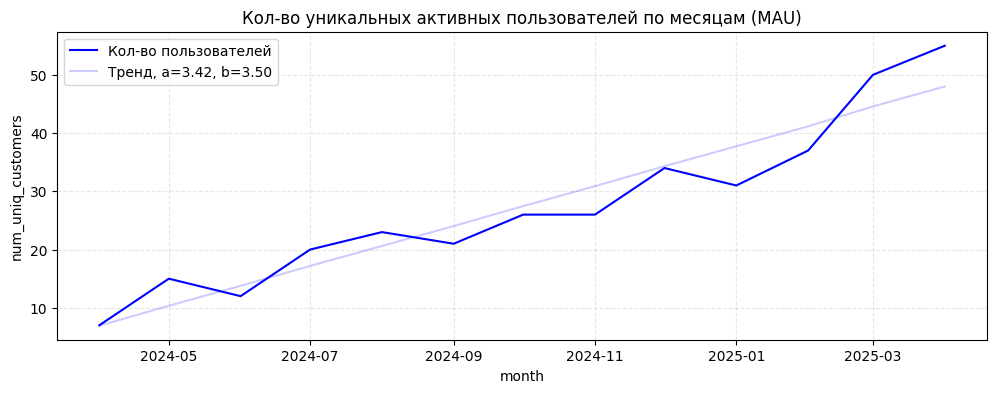

In [72]:
# Рассчитаем коэффициенты линейной регрессии для тренда
a, b = np.polyfit(np.arange(1,14), mau.num_uniq_customers, 1)

plt.figure(figsize=(12, 4))
plt.title('Кол-во уникальных активных пользователей по месяцам (MAU)')
sns.lineplot(data=mau , x='month', y='num_uniq_customers', color='blue', label='Кол-во пользователей')
#sns.lineplot(data=df_daily.assign(month = lambda df: df.EVENT_DATE.dt.to_period('M').dt.to_timestamp()), x='month', y='num_customers', color='blue', label='Кол-во пользователей', alpha=0.5)
plt.grid(True, linestyle="--", alpha=0.3)
sns.lineplot(data=mau , x='month', y=[a*i+b for i in np.arange(1,14)], color='blue', alpha=0.2, label=f'Тренд, a={a:.2f}, b={b:.2f}');

# Churtn Rate

> для анализа был исключен последний месяц - апрель 2025, т.к. для него нет данных за следующий месяц, необходимых для корректного определения оттока

Помимо одного запроса, возвращающего кол-во ушедших пользователей и churn_rate я подготовила и более интересный запрос, который маркирует пользователя по принадлежности к 4-м категориям (новый, удержанный, возвращенный и ушедший), при этом статус ушедшего может применяться к любому из статусов вхождения в текущем месяце.

- Ушедшим в текущем месяце пользователь считается в случае, если он не проявил активности в следующем месяце. В целом сдесь может быть вариабельность в понимании, и поэтому формализация понятий должна происходить на уровне компании (или хотя бы подразделения), но в любом случае должна быть доведена до ЛПР, чтобы не было искажения в восприятии.

- Добавление статуса "возвращенный" делает модель более гибкой и информативной, и отвечает на вопрос - куда относить "прыгающих" пользователей.

- Фиксированным окном для наблюдения выбран календарный месяц, хотя здесь тоже могут быть варианты

Основной рост обеспечивают удержанные (retained) и новые (new) пользователи.

**Удержанные** — это пользователи, у которых была совершена покупка в предыдущем месяце, они составляют основную массу активных пользователей. Видно, что количество удержанных пользователей растет стабильно каждый месяц, начиная с мая 2024.

**Новые** пользователи - это те, кто в текущем месяце впервые что то купил. Они вносят стабильный вклад, варьируясь от 4 до 12 в месяц. Рост без резких всплесков говорит о системном привлечении новых пользователей.

**Возвращенные** пользователи (Returning users) — это пользователи, не совершавшие покупку в предыдущем месяце (или ранее), но совершавшие до этого. Т.е. это те, кто прошли путь от new-> retained-> churned или  new-> churned.

Это показатель здоровья продукта.
Их количество хоть и невелико, но стабильно растёт, особенно с января 2025. Это хороший знак — значит, пользователи возвращаются к продукту после перерыва, что говорит о ценности и полезности.

**Ушедшие** (Churned) пользователи -  это те, кто не проявил активности в следующем месяце. Количество ушедших пользователей относительно стабильно (в среднем 3–5 в месяц), но в марте 2025 наблюдается резкий рост оттока — более 10 пользователей. Это сигнал потенциальной проблемы: либо пользователи не получили ценность, либо изменился продукт/условия использования.

In [224]:
# Простой запрос только по оттоку

query = '''
        select active.month, num_customers, coalesce(churn, 0) as churn,
          coalesce(churn*1.0/num_customers, 0) as churn_rate /*на 1.0 умножаю, чтобы привести к типу REAL*/
        from
            (select strftime("%Y-%m-01", event_date) as month, count(distinct user_id) as num_customers
            from df
            group by strftime("%Y-%m-01", event_date)) active
        left join
            (select month, count(USER_ID) as churn
            from
                (select USER_ID, strftime("%Y-%m-01", max(EVENT_DATE)) as month
                from df
                group by USER_ID) q
            group by month) churned
        on active.month=churned.month
        '''

churn = sqldf(query)
churn

,month,num_customers,churn,churn_rate
0,2024-04-01,7,0,0.000000
1,2024-05-01,15,3,0.200000
2,2024-06-01,12,4,0.333333
3,2024-07-01,20,1,0.050000
4,2024-08-01,23,3,0.130435
5,2024-09-01,21,2,0.095238
6,2024-10-01,26,6,0.230769
7,2024-11-01,26,4,0.153846
8,2024-12-01,34,4,0.117647
9,2025-01-01,31,3,0.096774


In [67]:
# Это запрос, который возвращает более полную картину и раскладывает MAU на структуру по 4-м статусам пользователей:
# новые, удержанные, возвращенные и ушедшие
query = '''
        /*Определяем уникальных пользователей за каждый месяц*/
        with user_months as (select  USER_ID, strftime('%Y-%m', EVENT_DATE) as month
            from df
            group by USER_ID, month),

        /*Для каждого пользователя  собираем все месяца с транзакциями и предшествующие им*/
        prev_activity as (select a.USER_ID, a.month, max(b.month) as last_month
            from user_months a
            left join user_months b
                on a.USER_ID = b.USER_ID
                and b.month < a.month
            group by a.USER_ID, a.month),

        /*Аналогичный запрос, только предшествующие месяца*/
        next_activity as (select a.USER_ID, a.month, min(b.month) as next_month
            from user_months a
            left join user_months b
                on a.USER_ID = b.USER_ID
                and b.month > a.month
            group by a.USER_ID, a.month),

        /*Определяем статус пользователя. Отточный может в тоже время быть новым, текущим и возвращенным*/
        monthly_classification as (select a.USER_ID, a.month,
                CASE WHEN pa.last_month IS NULL THEN 1 ELSE 0 END AS is_new,
                CASE WHEN pa.last_month IS NOT NULL AND strftime('%Y-%m', date(a.month || '-01', '-1 month')) = pa.last_month THEN 1 ELSE 0 END AS is_retained,
                CASE WHEN pa.last_month IS NOT NULL AND strftime('%Y-%m', date(a.month || '-01', '-1 month')) != pa.last_month THEN 1 ELSE 0 END AS is_returning,
                CASE WHEN na.next_month IS NULL THEN 1 ELSE 0 END AS is_churned
            from user_months a
            left join prev_activity pa on a.USER_ID = pa.USER_ID and a.month = pa.month
            left join next_activity na on a.USER_ID = na.USER_ID and a.month = na.month)

        /*Теперь просто агрегируем*/
        select month, sum(is_new) as new_users, sum(is_retained) as retained_users,
            sum(is_returning) as returning_users, sum(is_churned) as churned_users
        from monthly_classification
        group by month
        order by month;
        '''

churn_retention = sqldf(query)
churn_retention

,month,new_users,retained_users,returning_users,churned_users
0,2024-04,7,0,0,0
1,2024-05,9,6,0,3
2,2024-06,2,9,1,4
3,2024-07,10,8,2,1
4,2024-08,6,17,0,3
5,2024-09,3,17,1,2
6,2024-10,9,16,1,6
7,2024-11,7,16,3,4
8,2024-12,12,21,1,4
9,2025-01,4,25,2,3


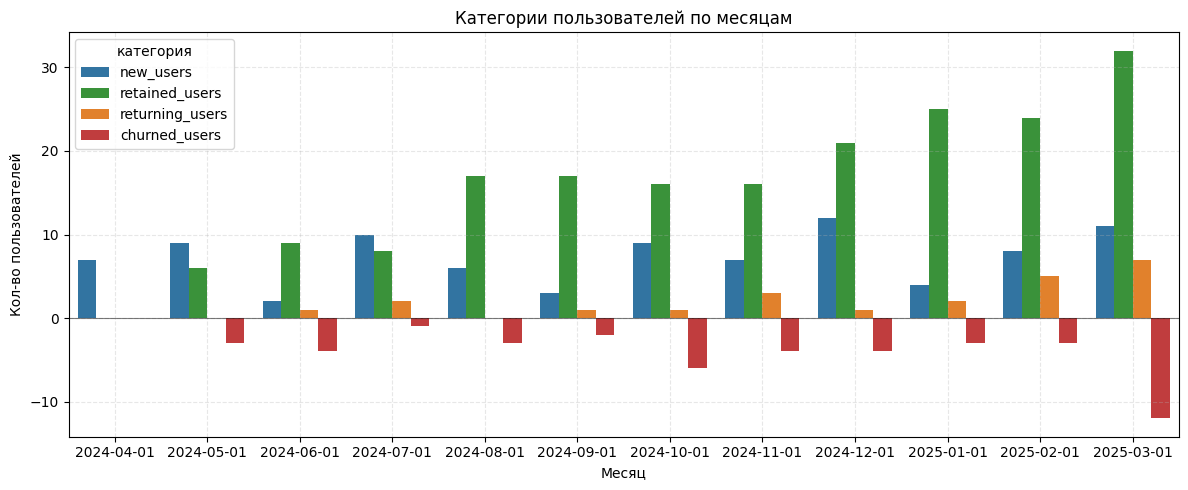

In [68]:
churn_retention_melted = churn_retention.assign(month = lambda df: pd.to_datetime(df.month)).iloc[:-1,:].assign(churned_users=lambda df: df.churned_users*-1).melt(id_vars='month', var_name='category', value_name='count')

plt.figure(figsize=(12, 5))
sns.barplot(data=churn_retention_melted, x='month', y='count', hue='category', palette={'new_users': 'tab:blue', 'retained_users': 'tab:green', 'returning_users': 'tab:orange', 'churned_users': 'tab:red'})

plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)
plt.title('Категории пользователей по месяцам')
plt.ylabel('Кол-во пользователей')
plt.xlabel('Месяц')
plt.legend(title='категория')
plt.tight_layout()
plt.grid(True, linestyle="--", alpha=0.3)
#plt.show()

Нормализуем все категории на количество активных пользователей (MAU) и получим Retention Rate, Churn Rate, Returning Rate, New_users Rate

Также посмотрим на такую метрику, как **new/churn** - она показывает уровень превышения притока новых пользователей над оттоком. Если new/churn > 1 - пользовательская база растет, если new/churn = 1 - бизнес только удерживает баланс, если new/churn < 1 - серьезный повод обеспокоится и предпринять какие-то меры.

In [69]:
# RR за апрель 2024 (так же как и CR в апреле 2025) не репрезентативен, т.к. в нем все пользователи новые
# RR показывает, какая доля активных пользователей MAU перешла из предыдущего месяца
# CR показывает, какая доля пользователей не совершила покупку в следующем месяце

churn_retention = churn_retention.assign(total_users = lambda df: df.new_users+df.retained_users+df.returning_users)\
  .assign(retention_rate = lambda df: df.retained_users/df.total_users)\
  .assign(returning_rate = lambda df: df.returning_users/df.total_users)\
  .assign(new_rate = lambda df: df.new_users/df.total_users)\
  .assign(churn_rate = lambda df: df.churned_users/df.total_users)\
  .assign(new_churn_ratio = lambda df: df.new_users/df.churned_users)

churn_retention

,month,new_users,retained_users,returning_users,churned_users,total_users,retention_rate,returning_rate,new_rate,churn_rate,new_churn_ratio
0,2024-04,7,0,0,0,7,0.000000,0.000000,1.000000,0.000000,inf
1,2024-05,9,6,0,3,15,0.400000,0.000000,0.600000,0.200000,3.000000
2,2024-06,2,9,1,4,12,0.750000,0.083333,0.166667,0.333333,0.500000
3,2024-07,10,8,2,1,20,0.400000,0.100000,0.500000,0.050000,10.000000
4,2024-08,6,17,0,3,23,0.739130,0.000000,0.260870,0.130435,2.000000
5,2024-09,3,17,1,2,21,0.809524,0.047619,0.142857,0.095238,1.500000
6,2024-10,9,16,1,6,26,0.615385,0.038462,0.346154,0.230769,1.500000
7,2024-11,7,16,3,4,26,0.615385,0.115385,0.269231,0.153846,1.750000
8,2024-12,12,21,1,4,34,0.617647,0.029412,0.352941,0.117647,3.000000
9,2025-01,4,25,2,3,31,0.806452,0.064516,0.129032,0.096774,1.333333


Поскольку все относительные показатели взаимосвязаны, очень удобно отсмотреть динамику структуры на штабелированном графике областей. Он показывает состав MAU по долям: кто пришёл, кто удержался, кто вернулся, а кто ушёл — в одной зоне на каждый месяц. Ушедшие отрисованы поверх структуры, т.к. база (MAU = 1) сформирована по вхождению, и ушедшие не должны учитываться дважды. Однако для сравнения их также удобно видеть на общем графике

Что ж, результат показывает хорошую устойчивость бизнеса и способность к дальнейшему росту- Retention Rate держится на уровне 0.6, приток новых пользователей и возвраты компенсируют и превышают отток, что хорошо видно по метрике new/churn (нижняя диаграмма lollipop chart)

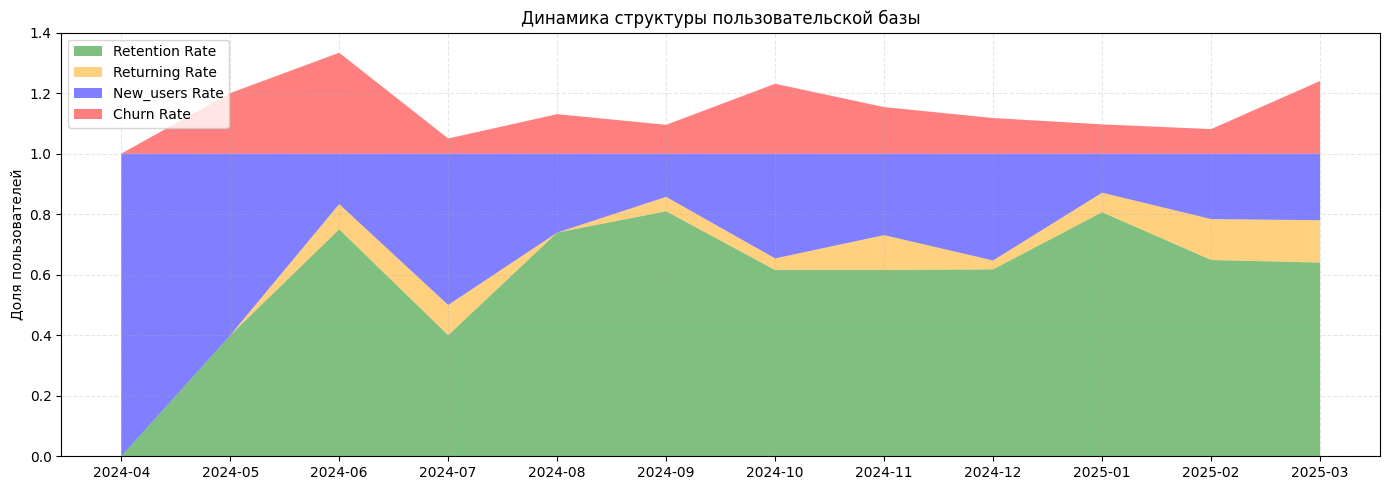

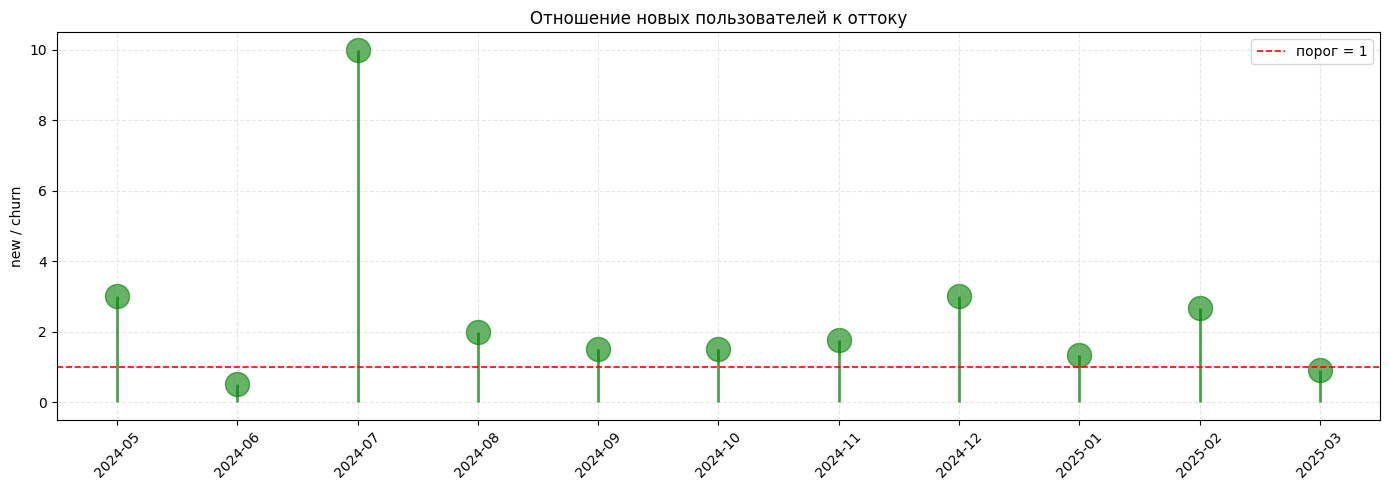

In [65]:
x = churn_retention.iloc[:-1]["month"]
y = [churn_retention.iloc[:-1]["retention_rate"], churn_retention.iloc[:-1]["returning_rate"], churn_retention.iloc[:-1]["new_rate"], churn_retention.iloc[:-1]["churn_rate"]]
labels = ["Retention Rate", "Returning Rate", "New_users Rate", "Churn Rate"]
colors = ["green", "orange", "blue", "red"]

plt.figure(figsize=(14, 5))
plt.stackplot(x, y, labels=labels, colors=colors, alpha=0.5)
plt.title("Динамика структуры пользовательской базы")
plt.legend(loc="upper left")
#plt.xticks(rotation=45)
plt.ylabel("Доля пользователей")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()

plt.figure(figsize=(14, 5))
plt.title("Отношение новых пользователей к оттоку")
plt.vlines(x=churn_retention.iloc[:-1]["month"], ymin=0, ymax=churn_retention.iloc[:-1]["new_churn_ratio"], color="green", alpha=0.7, linewidth=2)
plt.scatter(x=churn_retention.iloc[:-1]["month"], y=churn_retention.iloc[:-1]["new_churn_ratio"], color="green", s=300, alpha=0.6)
plt.axhline(1, color="red", linestyle="--", linewidth=1.2, label="порог = 1")
plt.ylabel("new / churn")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show();

# Когортный анализ

## Первый вариант когортной таблицы

Здесь сначала с помощью sql-запроса получаем агрегированное по месяцам покупок и месяцам первых покупок кол-во уникальных пользователей, а затем с помощью pandas (или excel) строим сводную таблицу. Преимущество этого варианта в том, что он не привязан к временному диапазону, потому что sql-синтаксис не позволяет строить внутри запроса сводные таблицы (к сожалению)


Когорта апреля 2024 самая сильная и долгоживущая -  из 7 пользователей 3 дожили до апреля 2025 года. Большинство когорт теряет 50%+ пользователей к 2-му месяцу. Плато удержания на уровне 1–2 пользователей (или ~20–30% от начальной когорты) устанавливается примерно с 5-го месяца во многих когортах (например, май, июнь, июль). Это указывает на стабильную, пусть и небольшую, лояльную аудиторию. Эффект "рассыпающихся" когорт особенно выражен в июне и сентябре 2024 и январе 2025 - они малочисленные, быстро редеют, могут наблюдаться редкие всплески вернувшихся

Проанализировав каналы привлечения, онбординг и UX для каждой из когорт рекомендуется учесть положительный опыт и провести корректировку пользовательского пути

In [89]:
query = '''
        select cohort, month, count(USER_ID) as num_users
        from
            (select distinct strftime("%Y-%m-01", EVENT_DATE) as month, USER_ID,
            min(strftime("%Y-%m-01", EVENT_DATE)) over (partition by USER_ID) as cohort
            from df) q
        group by cohort, month
        '''
cohort = sqldf(query)
cohort

,cohort,month,num_users
0,2024-04-01,2024-04-01,7
1,2024-04-01,2024-05-01,6
2,2024-04-01,2024-06-01,5
3,2024-04-01,2024-07-01,5
4,2024-04-01,2024-08-01,4
...,...,...,...
82,2025-02-01,2025-03-01,7
83,2025-02-01,2025-04-01,7
84,2025-03-01,2025-03-01,11
85,2025-03-01,2025-04-01,8


In [92]:
cohort.pivot(index='cohort', columns='month', values='num_users').fillna(0).astype(int).style.background_gradient(axis=1, cmap='YlGnBu').format("{:.0f}")

month,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01,2025-04-01
cohort,,,,,,,,,,,,,
2024-04-01,7,6,5,5,4,5,4,3,4,4,4,4,3
2024-05-01,0,9,5,4,3,2,2,2,2,2,2,2,3
2024-06-01,0,0,2,1,1,1,1,1,1,1,1,1,1
2024-07-01,0,0,0,10,9,6,6,4,4,3,3,7,4
2024-08-01,0,0,0,0,6,4,3,2,2,1,0,1,1
2024-09-01,0,0,0,0,0,3,1,2,1,0,1,0,0
2024-10-01,0,0,0,0,0,0,9,5,5,4,4,5,4
2024-11-01,0,0,0,0,0,0,0,7,3,3,4,4,3
2024-12-01,0,0,0,0,0,0,0,0,12,9,7,7,6


## Второй вариант когортной таблицы

Здесь пришлось жестко зафиксировать в запросе принадлежность пользователя к когорте, поэтому кол-во когорт должно быть заведомо известно. Другое отличие - здесь количество активных пользователей отслеживается не по календарному месяцу, а по порядковому месяцу активности. Такой формат также используется и не менее полезен

In [4]:
query = '''
        select cohort_month,
            sum(case when age_months = 0 then user_count else 0 end) as m_1,
            sum(case when age_months = 1 then user_count else 0 end) as m_2,
            sum(case when age_months = 2 then user_count else 0 end) as m_3,
            sum(case when age_months = 3 then user_count else 0 end) as m_4,
            sum(case when age_months = 4 then user_count else 0 end) as m_5,
            sum(case when age_months = 5 then user_count else 0 end) as m_6,
            sum(case when age_months = 6 then user_count else 0 end) as m_7,
            sum(case when age_months = 7 then user_count else 0 end) as m_8,
            sum(case when age_months = 8 then user_count else 0 end) as m_9,
            sum(case when age_months = 9 then user_count else 0 end) as m_10,
            sum(case when age_months = 10 then user_count else 0 end) as m_11,
            sum(case when age_months = 11 then user_count else 0 end) as m_12,
            sum(case when age_months = 12 then user_count else 0 end) as m_13
        from (
            with
            user_activity as (
                select USER_ID, date(EVENT_DATE) as event_date,
                    strftime('%Y-%m', EVENT_DATE) as activity_month
                from df),

            user_cohorts as
                (select USER_ID, min(activity_month) as cohort_month
                from user_activity
                group by USER_ID),

            cohort_events as
                (select ua.USER_ID, uc.cohort_month, ua.activity_month,
                    (cast(strftime('%Y', ua.activity_month || '-01') as integer) - cast(strftime('%Y', uc.cohort_month || '-01') as integer)) * 12 +
                    (cast(strftime('%m', ua.activity_month || '-01') as integer) - cast(strftime('%m', uc.cohort_month || '-01') as integer)) as age_months
                from user_activity ua
                join user_cohorts uc on ua.USER_ID = uc.USER_ID)

            select cohort_month, age_months, count(distinct USER_ID) as user_count
            from cohort_events
            group by cohort_month, age_months)

        group by cohort_month
        order by cohort_month;
        '''
cohort_2 = sqldf(query)
cohort_2

,cohort_month,m_1,m_2,m_3,m_4,m_5,m_6,m_7,m_8,m_9,m_10,m_11,m_12,m_13
0,2024-04,7,6,5,5,4,5,4,3,4,4,4,4,3
1,2024-05,9,5,4,3,2,2,2,2,2,2,2,3,0
2,2024-06,2,1,1,1,1,1,1,1,1,1,1,0,0
3,2024-07,10,9,6,6,4,4,3,3,7,4,0,0,0
4,2024-08,6,4,3,2,2,1,0,1,1,0,0,0,0
5,2024-09,3,1,2,1,0,1,0,0,0,0,0,0,0
6,2024-10,9,5,5,4,4,5,4,0,0,0,0,0,0
7,2024-11,7,3,3,4,4,3,0,0,0,0,0,0,0
8,2024-12,12,9,7,7,6,0,0,0,0,0,0,0,0
9,2025-01,4,3,1,3,0,0,0,0,0,0,0,0,0


In [105]:
cohort_2.style.background_gradient(axis=1, cmap='YlGnBu')#.format("{:.0f}")

,cohort_month,m_1,m_2,m_3,m_4,m_5,m_6,m_7,m_8,m_9,m_10,m_11,m_12,m_13
0,2024-04,7,6,5,5,4,5,4,3,4,4,4,4,3
1,2024-05,9,5,4,3,2,2,2,2,2,2,2,3,0
2,2024-06,2,1,1,1,1,1,1,1,1,1,1,0,0
3,2024-07,10,9,6,6,4,4,3,3,7,4,0,0,0
4,2024-08,6,4,3,2,2,1,0,1,1,0,0,0,0
5,2024-09,3,1,2,1,0,1,0,0,0,0,0,0,0
6,2024-10,9,5,5,4,4,5,4,0,0,0,0,0,0
7,2024-11,7,3,3,4,4,3,0,0,0,0,0,0,0
8,2024-12,12,9,7,7,6,0,0,0,0,0,0,0,0
9,2025-01,4,3,1,3,0,0,0,0,0,0,0,0,0


# Livetime

Для рассчета LT будем исходить из предположения, что компания только начала работать

Сейчас как раз очень пригодится второй вариант коготной таблицы, т.к. все когорты по времени выровнены относительно порядкого месяца, и на основе этого учень одобно посчитать retention

**Основные допущения и параметры расчёта:**

- По таблице и графику видно, что ни одна когорта не «исчерпалась» полностью — даже самая старая (апрель 2024) сохраняет 3 пользователей, что составляет 42% от изначального объёма. Таким образом, эталонная когорта, по которой можно было бы точно измерить LT, отсутствует.

- При этом апрельская когорта демонстрирует необычно высокий уровень удержания, что нехарактерно для остальных когорт. Вероятно, это связано с особенностями запуска (промо, приглашённые клиенты и т. п.). Возможно, её стоит исключить из расчёта, но это решение требует дополнительного контекстного анализа.

- Для корректного расчёта LT необходимо зафиксировать расчётное окно. В теории LT может быть бесконечным из-за "длинного хвоста", но для операционных целей стоит ограничивать его — например, 12–18 месяцами. Это снижает риск переоценки. В данной задаче за расчётное окно я беру 13 месяцев — соответствующее максимальному горизонту наблюдения.

- В RR (retention rate) заметны флуктуации: в некоторых месяцах пользователи возвращаются, из-за чего RR временно повышается. Это типичное поведение для когорты, особенно при нерегулярных сценариях использования.

**Методы оценки LT:**

1. **Наивный метод**

LT рассчитывается как сумма среднего RR по каждому месяцу жизни пользователя, без прогнозов и экстраполяций. Это простой и часто используемый способ, не требующий предсказания будущих значений.

2. **Метод с экстраполяцией Retention**

Обычно retention-кривая напоминает экспоненту: быстрый спад вначале, затем плато. Однако в данном кейсе наблюдается практически линейное снижение в первые 5 месяцев, а затем — выход на стабильный уровень. Поэтому вместо экспоненциальной модели я:

- отбираю когорты, прожившие 5 месяцев и более
- взвешиваю RR по размеру когорты
- пролонгирую последнее наблюдаемое значение RR на оставшиеся месяцы до конца окна (до 13 месяцев)
- таким образом формируется более реалистичная кривая для оценки LT.

Результат, полученный обоими способами, очень похож, и это хорошо. Всегда полезно иметь несколько оценок)

"Наивный" $LT_{13}$ - 191 день

Взвешенный $LT_{13}$ на основе экстраполяции - 190 дней

>Примечание: первый способ расчета LT можно реализовать sql-запросом, но на самом деле в этом не очень много полезности). Все таки полезнее и интереснее посмотреть на сами данные, как минимум чтобы отсмотреть поведение когорт, задетектить аномалии


In [5]:
retention = pd.concat([cohort_2[['cohort_month']], pd.DataFrame(np.array(cohort_2.iloc[:,1:]) / np.array(cohort_2['m_1'])[:, np.newaxis], columns=cohort_2.iloc[:,1:].columns)], axis=1).set_index('cohort_month')

# Нужно сделать один трюк - пропуски значений в месяце, который уже был, заполнить 0, а в недоступных для наблюдения оставить
mask = np.fliplr(np.triu(np.ones(retention.shape)))
mask[mask==0] = np.nan
retention = (retention*mask).reset_index()

retention.fillna('')

,cohort_month,m_1,m_2,m_3,m_4,m_5,m_6,m_7,m_8,m_9,m_10,m_11,m_12,m_13
0,2024-04,1.0,0.857143,0.714286,0.714286,0.571429,0.714286,0.571429,0.428571,0.571429,0.571429,0.571429,0.571429,0.428571
1,2024-05,1.0,0.555556,0.444444,0.333333,0.222222,0.222222,0.222222,0.222222,0.222222,0.222222,0.222222,0.333333,
2,2024-06,1.0,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,,
3,2024-07,1.0,0.9,0.6,0.6,0.4,0.4,0.3,0.3,0.7,0.4,,,
4,2024-08,1.0,0.666667,0.5,0.333333,0.333333,0.166667,0.0,0.166667,0.166667,,,,
5,2024-09,1.0,0.333333,0.666667,0.333333,0.0,0.333333,0.0,0.0,,,,,
6,2024-10,1.0,0.555556,0.555556,0.444444,0.444444,0.555556,0.444444,,,,,,
7,2024-11,1.0,0.428571,0.428571,0.571429,0.571429,0.428571,,,,,,,
8,2024-12,1.0,0.75,0.583333,0.583333,0.5,,,,,,,,
9,2025-01,1.0,0.75,0.25,0.75,,,,,,,,,


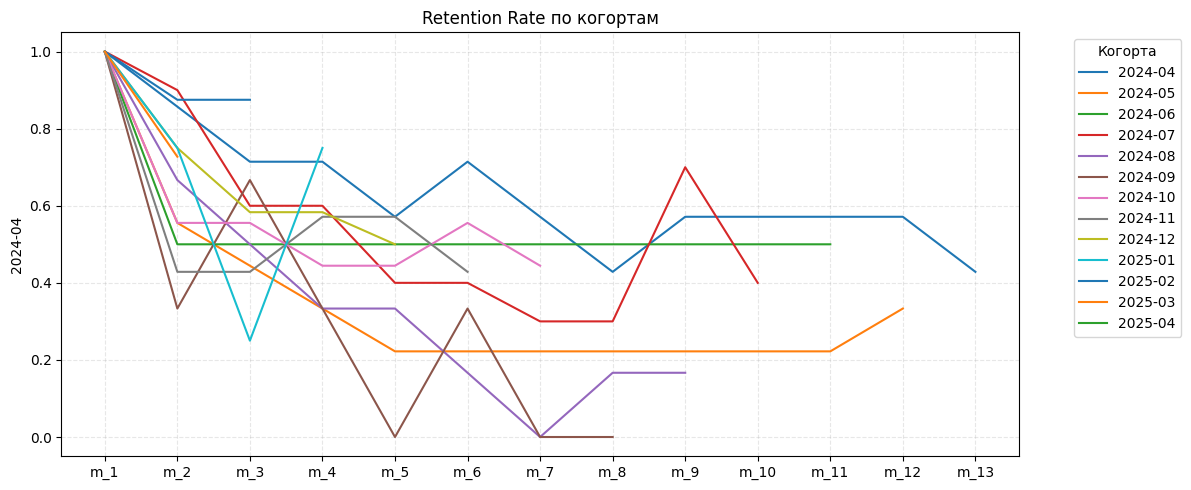

In [98]:
plt.figure(figsize=(12, 5))
plt.title('Retention Rate по когортам')

palette = sns.color_palette("tab10", n_colors=13)  # или "husl", "Set2", "Paired" и др.
for color, month in zip(palette, retention.cohort_month):
    sns.lineplot(data=retention.set_index('cohort_month').T[month], color=color, label=month)
plt.legend(title="Когорта", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

## Наивный LT

In [119]:
print(f'LT пользователей на горизонте 13 месяцев = {np.mean(retention.iloc[:, 1:], axis=0).sum():.1f} месяцев или {np.mean(retention.iloc[:, 1:], axis=0).sum()*365/12:.0f} дней')

LT пользователей на горизонте 13 месяцев = 6.3 месяцев или 191 дней


## LT с экстраполяцией и взвешиванием

In [116]:
# Отбираем когорты у которых >= 5 месяцев наблюдения, т.е. до декабря 2024 включительно
retention_trunc = retention.iloc[:-4, 1:].values

for i in range(len(retention_trunc)):
    retention_trunc[i,:][np.isnan(retention_trunc[i,:])]=retention_trunc[i,:][~np.isnan(retention_trunc[i,:])][-1]

# определяем вес каждой когорты по доле пользователей в когорте от общего числа
weights = cohort_2['m_1'].values[:-4]/(cohort_2['m_1'].values[:-4].sum())

# посчитаем взвешенную кривую retention
weighted_retention_curve = np.average(retention_trunc, axis=0, weights=weights)

print(f'LT пользователей на горизонте 13 месяцев = {weighted_retention_curve.sum():.1f} месяцев или {weighted_retention_curve.sum()*365/12:.0f} дней')

LT пользователей на горизонте 13 месяцев = 6.3 месяцев или 190 дней


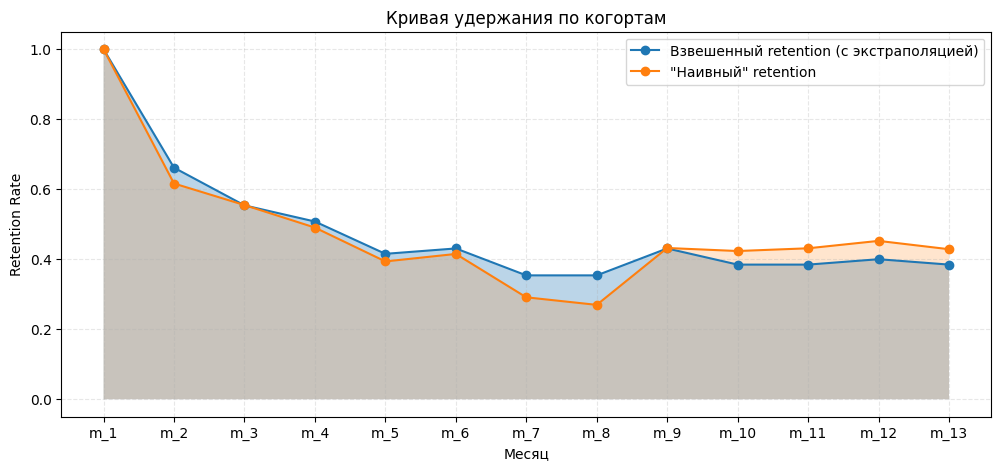

In [117]:
plt.figure(figsize=(12, 5))
plt.plot(weighted_retention_curve, marker='o', label='Взвешенный retention (с экстраполяцией)')
plt.fill_between(range(len(weighted_retention_curve)), weighted_retention_curve, alpha=0.3)
plt.plot(np.mean(retention.iloc[:-4, 1:], axis=0), marker='o', label='"Наивный" retention')
plt.fill_between(range(len(weighted_retention_curve)), np.mean(retention.iloc[:-4, 1:], axis=0), alpha=0.2)
plt.grid(True, linestyle='--', alpha=0.3)
plt.title('Кривая удержания по когортам')
plt.xlabel('Месяц')
plt.ylabel('Retention Rate')
plt.legend()
plt.show()